### Introducción a la Base de Datos

Esta base de datos contiene información detallada sobre la **deserción en la formación profesional integral**. Básicamente, nos permite entender cuántos estudiantes abandonan sus programas de estudio y bajo qué circunstancias. Incluye datos sobre los **centros de formación**, las **modalidades de estudio** (como presencial o virtual), los **niveles de formación** (como técnico o tecnólogo), el **número total de aprendices matriculados** y la cantidad de **desertores** en el año 2026.

**Objetivo**: Identificar qué centros de formación, modalidades y niveles educativos presentan mayor deserción, para aportar puntos de partida a estrategias de retención.

### 5 Preguntas de Investigación para esta Base de Datos

1. ¿Qué centros de formación tienen mayor deserción (en número absoluto y en
porcentaje)?
2. ¿La modalidad de estudio (presencial, virtual, a distancia) influye en la deserción?
3. ¿Hay niveles de formación con mayor deserción que otros?
4. ¿Qué tan asociados están el nivel de formación y la modalidad?
5. ¿Existe relación entre el tamaño de una ficha (matriculados) y la tasa de deserción?

In [6]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

In [5]:
file_path = '/content/DESERCION_DE_LA_FORMACIÓN_PROFESIONAL_INTEGRAL_20260807.csv'

try:
    df = pd.read_csv(file_path)
    print("CSV data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

CSV data loaded successfully!


,CODIGO_REGIONAL,NOMBRE_REGIONAL,CODIGO_CENTRO,NOMBRE_CENTRO,IDENTIFICADOR_UNICO_FICHA,FECHA_INICIO_FICHA,FECHA_TERMINACION_FICHA,CODIGO_PROGRAMA,VERSION_PROGRAMA,NOMBRE_PROGRAMA_FORMACION,NIVEL_FORMACION,MODALIDAD_FORMACION,TOTAL_APRENDICES_MATRICULADOS,DESERTORES_AÑO_ACTUAL,PERIODO
0,13,"""REGIONAL BOLIVAR""",9304,"""CENTRO DE COMERCIO Y SERVICIOS""",12709991,"""27/02/2023""","""16/12/2024""","""635503""",103,"""COCINA.""","""TECNICO""","""PRESENCIAL""",33,0,202.402
1,19,"""REGIONAL CAUCA""",9113,"""CENTRO AGROPECUARIO""",12860879,"""17/10/2023""","""01/03/2025""","""635604""",1,"""SERVICIOS DE BARISMO""","""TECNICO""","""PRESENCIAL""",21,0,202.402
2,76,"""REGIONAL VALLE""",9544,"""CENTRO DE BIOTECNOLOGIA INDUSTRIAL""",12710859,"""27/02/2023""","""16/12/2024""","""233101""",1,"""SISTEMAS.""","""TECNICO""","""PRESENCIAL""",39,0,202.402
3,19,"""REGIONAL CAUCA""",9113,"""CENTRO AGROPECUARIO""",12615282,"""06/10/2022""","""05/10/2024""","""112005""",101,"""GESTION DEL TALENTO HUMANO""","""TECNOLOGO""","""PRESENCIAL""",24,0,202.402
4,20,"""REGIONAL CESAR""",9520,"""CENTRO AGROEMPRESARIAL""",12715260,"""06/03/2023""","""13/12/2024""","""134200""",2,"""RECURSOS HUMANOS .""","""TECNICO""","""PRESENCIAL""",24,0,202.402


In [7]:
print('Filas: ', df.shape[0])
print('Columnas: ', df.shape[1])

Filas:  42080
Columnas:  15


In [12]:
df.columns

Index(['CODIGO_REGIONAL', 'NOMBRE_REGIONAL', 'CODIGO_CENTRO', 'NOMBRE_CENTRO',
       'IDENTIFICADOR_UNICO_FICHA', 'FECHA_INICIO_FICHA',
       'FECHA_TERMINACION_FICHA', 'CODIGO_PROGRAMA', 'VERSION_PROGRAMA',
       'NOMBRE_PROGRAMA_FORMACION', 'NIVEL_FORMACION', 'MODALIDAD_FORMACION',
       'TOTAL_APRENDICES_MATRICULADOS', 'DESERTORES_AÑO_ACTUAL', 'PERIODO'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42080 entries, 0 to 42079
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CODIGO_REGIONAL                42080 non-null  int64  
 1   NOMBRE_REGIONAL                42080 non-null  object 
 2   CODIGO_CENTRO                  42080 non-null  int64  
 3   NOMBRE_CENTRO                  42080 non-null  object 
 4   IDENTIFICADOR_UNICO_FICHA      42080 non-null  int64  
 5   FECHA_INICIO_FICHA             42080 non-null  object 
 6   FECHA_TERMINACION_FICHA        42080 non-null  object 
 7   CODIGO_PROGRAMA                42080 non-null  object 
 8   VERSION_PROGRAMA               42080 non-null  int64  
 9   NOMBRE_PROGRAMA_FORMACION      42080 non-null  object 
 10  NIVEL_FORMACION                42080 non-null  object 
 11  MODALIDAD_FORMACION            42080 non-null  object 
 12  TOTAL_APRENDICES_MATRICULADOS  42080 non-null 

In [10]:
df.dtypes

,0
CODIGO_REGIONAL,int64
NOMBRE_REGIONAL,object
CODIGO_CENTRO,int64
NOMBRE_CENTRO,object
IDENTIFICADOR_UNICO_FICHA,int64
FECHA_INICIO_FICHA,object
FECHA_TERMINACION_FICHA,object
CODIGO_PROGRAMA,object
VERSION_PROGRAMA,int64
NOMBRE_PROGRAMA_FORMACION,object


In [13]:
cualicolumns=df.select_dtypes(exclude=['int64','float64','datetime64']).columns
cuanticolumns=df.select_dtypes(exclude=['object','datetime64']).columns
fechacolumns=df.select_dtypes(exclude=['object','float64','int64']).columns

In [14]:
print('El número de variables categóricas es de: ', len(cualicolumns)),
print('El número de variables cuantitativas es de: ', len(cuanticolumns)),
print('El número de variables tipo fecha es de: ', len(fechacolumns))

El número de variables categóricas es de:  8
El número de variables cuantitativas es de:  7
El número de variables tipo fecha es de:  0


In [15]:
df.head(5)

,CODIGO_REGIONAL,NOMBRE_REGIONAL,CODIGO_CENTRO,NOMBRE_CENTRO,IDENTIFICADOR_UNICO_FICHA,FECHA_INICIO_FICHA,FECHA_TERMINACION_FICHA,CODIGO_PROGRAMA,VERSION_PROGRAMA,NOMBRE_PROGRAMA_FORMACION,NIVEL_FORMACION,MODALIDAD_FORMACION,TOTAL_APRENDICES_MATRICULADOS,DESERTORES_AÑO_ACTUAL,PERIODO
0,13,"""REGIONAL BOLIVAR""",9304,"""CENTRO DE COMERCIO Y SERVICIOS""",12709991,"""27/02/2023""","""16/12/2024""","""635503""",103,"""COCINA.""","""TECNICO""","""PRESENCIAL""",33,0,202.402
1,19,"""REGIONAL CAUCA""",9113,"""CENTRO AGROPECUARIO""",12860879,"""17/10/2023""","""01/03/2025""","""635604""",1,"""SERVICIOS DE BARISMO""","""TECNICO""","""PRESENCIAL""",21,0,202.402
2,76,"""REGIONAL VALLE""",9544,"""CENTRO DE BIOTECNOLOGIA INDUSTRIAL""",12710859,"""27/02/2023""","""16/12/2024""","""233101""",1,"""SISTEMAS.""","""TECNICO""","""PRESENCIAL""",39,0,202.402
3,19,"""REGIONAL CAUCA""",9113,"""CENTRO AGROPECUARIO""",12615282,"""06/10/2022""","""05/10/2024""","""112005""",101,"""GESTION DEL TALENTO HUMANO""","""TECNOLOGO""","""PRESENCIAL""",24,0,202.402
4,20,"""REGIONAL CESAR""",9520,"""CENTRO AGROEMPRESARIAL""",12715260,"""06/03/2023""","""13/12/2024""","""134200""",2,"""RECURSOS HUMANOS .""","""TECNICO""","""PRESENCIAL""",24,0,202.402


In [16]:
df.tail()

,CODIGO_REGIONAL,NOMBRE_REGIONAL,CODIGO_CENTRO,NOMBRE_CENTRO,IDENTIFICADOR_UNICO_FICHA,FECHA_INICIO_FICHA,FECHA_TERMINACION_FICHA,CODIGO_PROGRAMA,VERSION_PROGRAMA,NOMBRE_PROGRAMA_FORMACION,NIVEL_FORMACION,MODALIDAD_FORMACION,TOTAL_APRENDICES_MATRICULADOS,DESERTORES_AÑO_ACTUAL,PERIODO
42075,73,"""REGIONAL TOLIMA""",9310,"""CENTRO DE COMERCIO Y SERVICIOS""",12721103,"""13/03/2023""","""12/06/2024""","""133100""",2,"""CONTABILIZACION DE OPERACIONES COMERCIALES Y ...","""TECNICO""","""PRESENCIAL""",21,0,202.402
42076,54,"""REGIONAL NORTE DE SANTANDER""",9119,"""CENTRO DE FORMACION PARA EL DESARROLLO RURAL ...",12921097,"""21/02/2024""","""29/02/2024""","""21730067""",1,"""INFORMATICA: MICROSOFT WORD, EXCEL E INTERNET""","""CURSO ESPECIAL""","""PRESENCIAL""",25,0,202.402
42077,76,"""REGIONAL VALLE""",9544,"""CENTRO DE BIOTECNOLOGIA INDUSTRIAL""",12909905,"""09/02/2024""","""13/03/2024""","""51240087""",1,"""ENGLISH DOES WORK - LEVEL 1""","""CURSO ESPECIAL""","""VIRTUAL""",80,3,202.402
42078,5,"""REGIONAL ANTIOQUIA""",9201,"""CENTRO DEL DISEÑO Y MANUFACTURA DEL CUERO""",12709074,"""01/03/2023""","""13/12/2024""","""134200""",2,"""RECURSOS HUMANOS .""","""TECNICO""","""PRESENCIAL""",28,0,202.402
42079,25,"""REGIONAL CUNDINAMARCA""",9513,"""CENTRO DE DESARROLLO AGROEMPRESARIAL""",12669298,"""23/01/2023""","""22/01/2025""","""112005""",101,"""GESTION DEL TALENTO HUMANO""","""TECNOLOGO""","""PRESENCIAL""",27,0,202.402


In [17]:
df.describe()

,CODIGO_REGIONAL,CODIGO_CENTRO,IDENTIFICADOR_UNICO_FICHA,VERSION_PROGRAMA,TOTAL_APRENDICES_MATRICULADOS,DESERTORES_AÑO_ACTUAL,PERIODO
count,42080.000000,42080.000000,4.208000e+04,42080.000000,42080.000000,42080.000000,4.208000e+04
mean,35.768227,9334.255751,1.275734e+07,10.981369,34.391730,1.249501,2.024020e+02
std,28.181405,159.473480,6.210224e+05,29.492726,21.347398,6.435441,1.595898e-10
min,5.000000,9101.000000,2.300927e+06,1.000000,1.000000,0.000000,2.024020e+02
25%,11.000000,9208.000000,1.270518e+07,1.000000,22.000000,0.000000,2.024020e+02
50%,23.000000,9305.000000,1.282403e+07,1.000000,27.000000,0.000000,2.024020e+02
75%,66.000000,9515.000000,1.290979e+07,2.000000,35.000000,0.000000,2.024020e+02
max,99.000000,9549.000000,1.293324e+07,104.000000,208.000000,84.000000,2.024020e+02


In [18]:
#Número de desertores por centro de formación
deserters_by_center = df.groupby('NOMBRE_CENTRO')['DESERTORES_AÑO_ACTUAL'].sum().sort_values(ascending=False)
display(deserters_by_center)

,DESERTORES_AÑO_ACTUAL
NOMBRE_CENTRO,
"""CENTRO DE COMERCIO Y SERVICIOS""",9807
"""CENTRO DE MATERIALES Y ENSAYOS""",2323
"""CENTRO INDUSTRIAL DEL DISEÑO Y LA MANUFACTURA""",1475
"""CENTRO DE DISEÑO TECNOLOGICO INDUSTRIAL""",1262
"""CENTRO DE INDUSTRIA Y CONSTRUCCION""",1074
...,...
"""CENTRO SUR COLOMBIANO DE LOGISTICA INTERNACIONAL""",27
"""CENTRO AGROEMPRESARIAL Y ACUICOLA""",19
"""CENTRO AMBIENTAL Y ECOTURISTICO DEL NORORIENTE AMAZONICO""",15


Grafica los centros de formación con más desertores usando un gráfico de barras

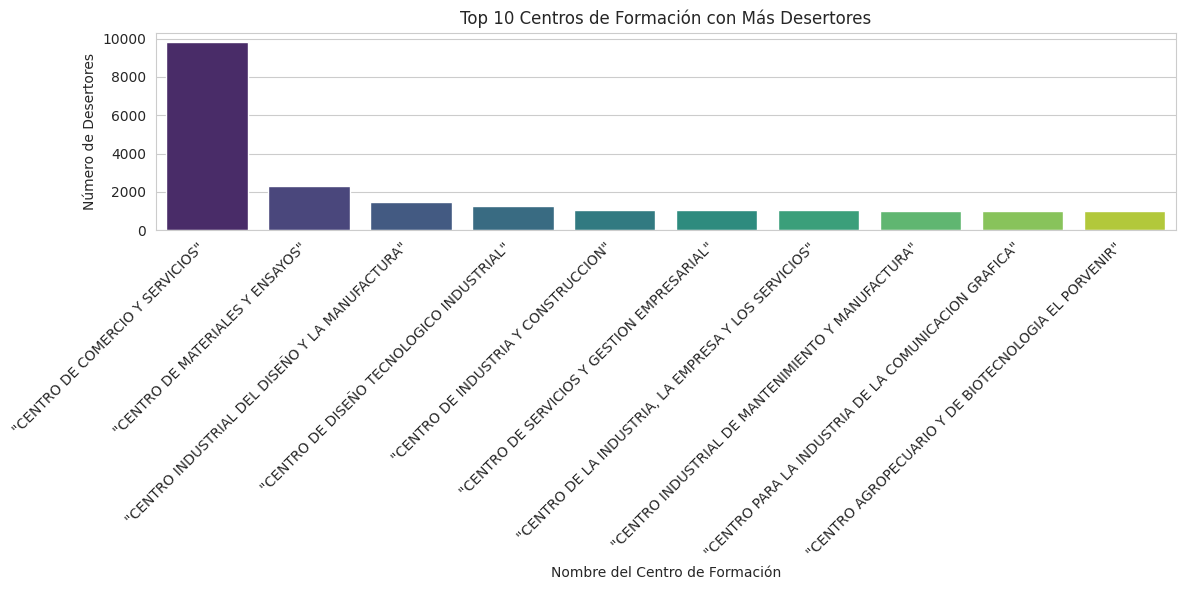

In [19]:
#Gráfica de los 10 centro de formación donde hay más desertores
plt.figure(figsize=(12, 6))
sns.barplot(x=deserters_by_center.head(10).index, y=deserters_by_center.head(10).values, palette='viridis', hue=deserters_by_center.head(10).index, legend=False)
plt.title('Top 10 Centros de Formación con Más Desertores')
plt.xlabel('Nombre del Centro de Formación')
plt.ylabel('Número de Desertores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
#Número total de aprendices matriculados por centro
total_matriculated_by_center = df.groupby('NOMBRE_CENTRO')['TOTAL_APRENDICES_MATRICULADOS'].sum()

desertion_percentage_by_center = (deserters_by_center / total_matriculated_by_center * 100).sort_values(ascending=False)
display(desertion_percentage_by_center.head(10))

,0
NOMBRE_CENTRO,
"""CENTRO PARA LA BIODIVERSIDAD Y EL TURISMO DEL AMAZONAS""",18.819095
"""CENTRO DE MATERIALES Y ENSAYOS""",16.100638
"""CENTRO DE DISEÑO TECNOLOGICO INDUSTRIAL""",15.276601
"""CENTRO AGROPECUARIO Y DE SERVICIOS AMBIENTALES JIRI - JIRIMO""",13.573407
"""CENTRO DE GESTION INDUSTRIAL""",12.412208
"""CENTRO INDUSTRIAL DEL DISEÑO Y LA MANUFACTURA""",11.834082
"""CENTRO NACIONAL DE ASISTENCIA TECNICA A LA INDUSTRIA - ASTIN""",11.083830
"""CENTRO PARA LA INDUSTRIA DE LA COMUNICACION GRAFICA""",10.355341
"""COMPLEJO TECNOLOGICO PARA LA GESTION AGROEMPRESARIAL""",10.000000


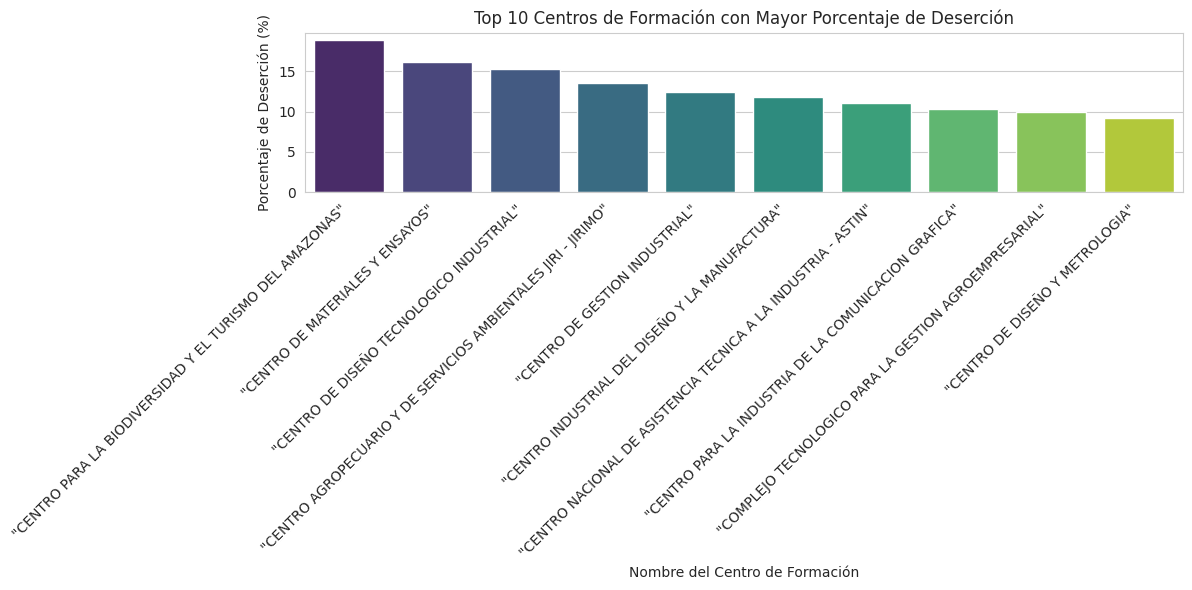

In [21]:
#Calculo del porcentaje de deserción para cada modalidad de formación.
plt.figure(figsize=(12, 6))
sns.barplot(x=desertion_percentage_by_center.head(10).index, y=desertion_percentage_by_center.head(10).values, palette='viridis', hue=desertion_percentage_by_center.head(10).index, legend=False)
plt.title('Top 10 Centros de Formación con Mayor Porcentaje de Deserción')
plt.xlabel('Nombre del Centro de Formación')
plt.ylabel('Porcentaje de Deserción (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
#Calculo del porcentaje de deserción para cada modalidad de formación.
deserters_by_modality = df.groupby('MODALIDAD_FORMACION')['DESERTORES_AÑO_ACTUAL'].sum()
total_matriculated_by_modality = df.groupby('MODALIDAD_FORMACION')['TOTAL_APRENDICES_MATRICULADOS'].sum()

desertion_percentage_by_modality = (deserters_by_modality / total_matriculated_by_modality * 100).sort_values(ascending=False)
display(desertion_percentage_by_modality)

,0
MODALIDAD_FORMACION,
"""VIRTUAL""",6.235399
"""A DISTANCIA""",2.403846
"""PRESENCIAL""",1.598271


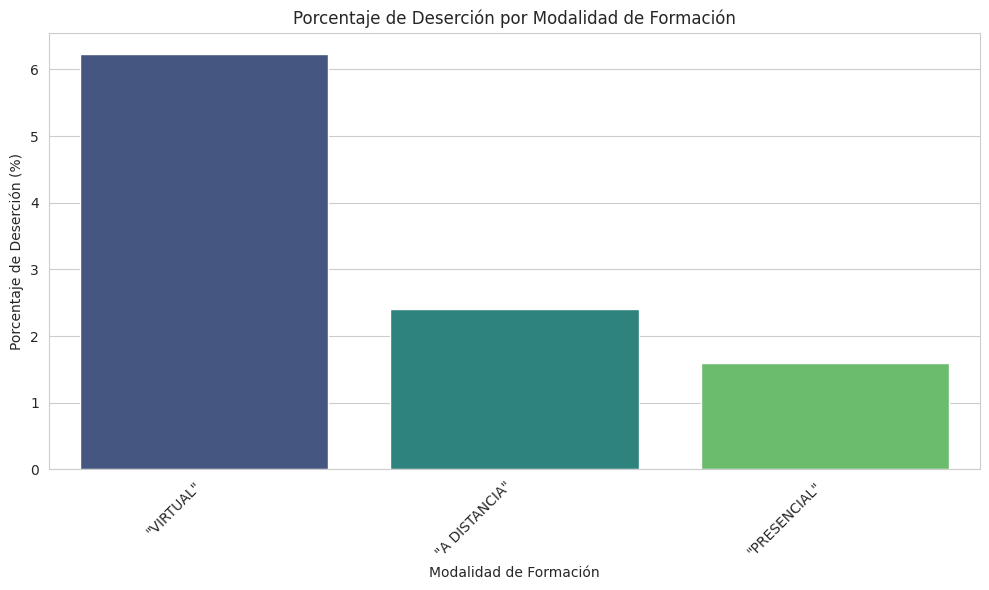

In [23]:
#Gráfico de barras comparando la deserción por modalidad
plt.figure(figsize=(10, 6))
sns.barplot(x=desertion_percentage_by_modality.index, y=desertion_percentage_by_modality.values, palette='viridis', hue=desertion_percentage_by_modality.index, legend=False)
plt.title('Porcentaje de Deserción por Modalidad de Formación')
plt.xlabel('Modalidad de Formación')
plt.ylabel('Porcentaje de Deserción (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análisis de Deserción por Nivel de Formación

Ahora, investiguemos si el nivel de formación juega un papel en la tasa de deserción. Para ello, calcularemos el porcentaje de deserción para cada nivel de formación.

In [25]:
# Calcular el número total de desertores por nivel de formación
deserters_by_education_level = df.groupby('NIVEL_FORMACION')['DESERTORES_AÑO_ACTUAL'].sum()

# Calcular el número total de aprendices matriculados por nivel de formación
total_matriculated_by_education_level = df.groupby('NIVEL_FORMACION')['TOTAL_APRENDICES_MATRICULADOS'].sum()

# Calcular el porcentaje de deserción por nivel de formación
desertion_percentage_by_education_level = (deserters_by_education_level / total_matriculated_by_education_level * 100).sort_values(ascending=False)

display(desertion_percentage_by_education_level)

,0
NIVEL_FORMACION,
"""EVENTO""",10.438926
"""CURSO ESPECIAL""",5.354123
"""OPERARIO""",4.410630
"""TECNOLOGO""",2.137503
"""AUXILIAR""",1.815690
"""TECNICO""",1.625351
"""PROFUNDIZACION TECNICA""",0.000000


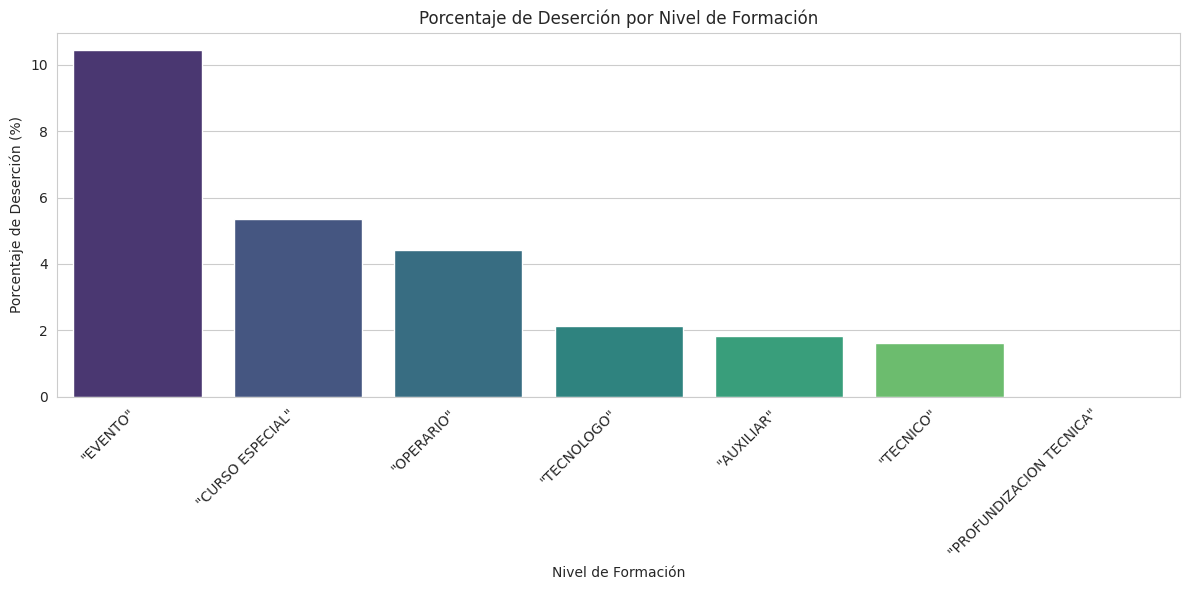

In [26]:
# Gráfico de barras comparando la deserción por nivel de formación
plt.figure(figsize=(12, 6))
sns.barplot(x=desertion_percentage_by_education_level.index, y=desertion_percentage_by_education_level.values, palette='viridis', hue=desertion_percentage_by_education_level.index, legend=False)
plt.title('Porcentaje de Deserción por Nivel de Formación')
plt.xlabel('Nivel de Formación')
plt.ylabel('Porcentaje de Deserción (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Los Centros de Formación: Identificamos los
centros con mayor número absoluto de desertores y también aquellos con el porcentaje de deserción más alto, notando que no siempre son los mismos. Esto sugiere que centros con muchos alumnos pueden tener un alto número de desertores pero un porcentaje bajo, mientras que centros más pequeños pueden tener un porcentaje de deserción preocupante.

Modalidad de Formación: La modalidad "VIRTUAL" presenta el porcentaje de deserción más alto (6.24%), seguida por "A DISTANCIA" (2.40%) y "PRESENCIAL" (1.60%). Esto indica que la virtualidad puede ser un factor que contribuye a una mayor tasa de deserción.

Nivel de Formación: El nivel de formación "EVENTO" tiene el porcentaje de deserción más alto (10.44%), seguido por "CURSO ESPECIAL" (5.35%) y "OPERARIO" (4.41%). La "PROFUNDIZACION TECNICA" no registra deserción.

En general, este análisis nos ha permitido identificar patrones importantes en la deserción estudiantil, destacando áreas específicas donde se podrían enfocar esfuerzos para mejorar la retención de los aprendices.

### Correlación entre Nivel de Formación y Modalidad

Para calcular la "correlación" entre dos variables categóricas como el Nivel de Formación y la Modalidad, no podemos usar métodos tradicionales como el coeficiente de Pearson. En su lugar, utilizaremos una tabla de contingencia y el coeficiente V de Cramer, que nos indicará la fuerza de la asociación entre estas variables.

In [27]:
from scipy.stats import chi2_contingency

# Crear la tabla de contingencia
contingency_table = pd.crosstab(df['NIVEL_FORMACION'], df['MODALIDAD_FORMACION'])
display(contingency_table)

MODALIDAD_FORMACION,"""A DISTANCIA""","""PRESENCIAL""","""VIRTUAL"""
NIVEL_FORMACION,,,
"""AUXILIAR""",0,128,0
"""CURSO ESPECIAL""",4,7729,6552
"""EVENTO""",0,142,0
"""OPERARIO""",0,423,0
"""PROFUNDIZACION TECNICA""",0,11,0
"""TECNICO""",13,15949,870
"""TECNOLOGO""",127,7962,2170


In [28]:
# Calcular el estadístico chi-cuadrado y los grados de libertad
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Calcular el coeficiente V de Cramer
n = contingency_table.sum().sum()
V_cramer = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Estadístico Chi-cuadrado: {chi2:.2f}")
print(f"Valor p: {p_value:.3f}")
print(f"V de Cramer: {V_cramer:.2f}")

# Interpretar el valor de V de Cramer
if V_cramer < 0.1:
    print("Asociación muy débil o inexistente.")
elif V_cramer < 0.3:
    print("Asociación débil.")
elif V_cramer < 0.5:
    print("Asociación moderada.")
else:
    print("Asociación fuerte.")

Estadístico Chi-cuadrado: 7834.43
Valor p: 0.000
V de Cramer: 0.31
Asociación moderada.


### Visualización de la Relación entre Nivel de Formación y Modalidad (Mapa de Calor)

Para una comprensión visual más clara de la relación entre el nivel de formación y la modalidad, utilizaremos un mapa de calor basado en la tabla de contingencia. Esto nos permitirá identificar rápidamente los pares de nivel-modalidad con mayor frecuencia.

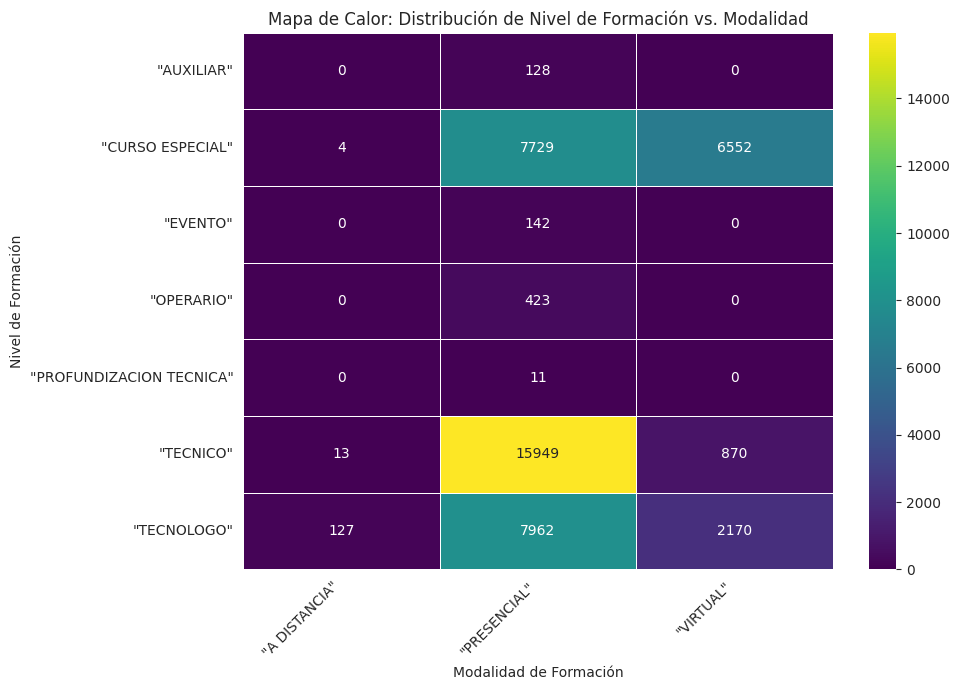

In [29]:
plt.figure(figsize=(10, 7))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Mapa de Calor: Distribución de Nivel de Formación vs. Modalidad')
plt.xlabel('Modalidad de Formación')
plt.ylabel('Nivel de Formación')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Análisis de Deserción por Periodo Académico

Para entender cómo el periodo académico influye en la tasa de deserción, primero necesitamos examinar los valores en la columna `PERIODO` para asegurarnos de que hay suficiente variación para un análisis significativo.

In [30]:
print("Valores únicos en la columna 'PERIODO':")
display(df['PERIODO'].unique())
print(f"Número de valores únicos en 'PERIODO': {df['PERIODO'].nunique()}")

Valores únicos en la columna 'PERIODO':


array([202.402])

Número de valores únicos en 'PERIODO': 1


### Coeficiente de Correlación entre Deserción y Número de Matriculados

Vamos a calcular el coeficiente de correlación de Pearson para entender la relación lineal entre el número de aprendices matriculados y la cantidad de desertores.

In [31]:
correlation = df['DESERTORES_AÑO_ACTUAL'].corr(df['TOTAL_APRENDICES_MATRICULADOS'])
print(f"Coeficiente de correlación entre Deserción y Matriculados: {correlation:.2f}")

# Interpretar la correlación
if correlation > 0.7:
    print("Existe una fuerte correlación positiva: a mayor número de matriculados, mayor es el número de desertores.")
elif correlation > 0.3:
    print("Existe una correlación positiva moderada: a mayor número de matriculados, tiende a haber un mayor número de desertores.")
elif correlation > 0:
    print("Existe una correlación positiva débil: hay una ligera tendencia a que más matriculados se asocien con más desertores.")
elif correlation < -0.7:
    print("Existe una fuerte correlación negativa: a mayor número de matriculados, menor es el número de desertores.")
elif correlation < -0.3:
    print("Existe una correlación negativa moderada: a mayor número de matriculados, tiende a haber un menor número de desertores.")
elif correlation < 0:
    print("Existe una correlación negativa débil: hay una ligera tendencia a que más matriculados se asocien con menos desertores.")
else:
    print("No existe una correlación lineal significativa entre el número de matriculados y el número de desertores.")

Coeficiente de correlación entre Deserción y Matriculados: 0.27
Existe una correlación positiva débil: hay una ligera tendencia a que más matriculados se asocien con más desertores.


### Gráfico de Caja (Boxplot): Deserción por Modalidad de Formación

Este boxplot nos mostrará la distribución de la cantidad de desertores para cada modalidad de formación, permitiendo identificar la mediana, los cuartiles y posibles valores atípicos.

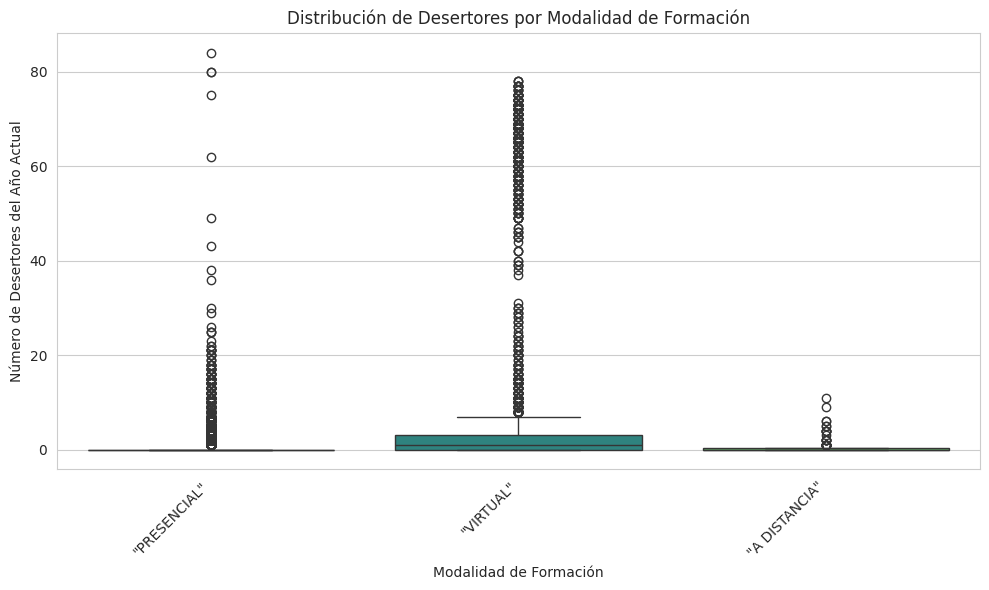

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='MODALIDAD_FORMACION', y='DESERTORES_AÑO_ACTUAL', data=df, palette='viridis', hue='MODALIDAD_FORMACION', legend=False)
plt.title('Distribución de Desertores por Modalidad de Formación')
plt.xlabel('Modalidad de Formación')
plt.ylabel('Número de Desertores del Año Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Prueba H de Kruskal-Wallis para Comparar la Deserción entre Modalidades

Utilizaremos la prueba H de Kruskal-Wallis para determinar si existen diferencias estadísticamente significativas en el número de desertores entre las distintas modalidades de formación. Esta prueba es una alternativa no paramétrica al ANOVA de una vía y es adecuada cuando los supuestos de normalidad no se cumplen.

In [35]:
from scipy.stats import kruskal

# Obtener los datos de desertores para cada modalidad
modalities = df['MODALIDAD_FORMACION'].unique()
desertores_por_modalidad = [df[df['MODALIDAD_FORMACION'] == m]['DESERTORES_AÑO_ACTUAL'] for m in modalities]

# Realizar la prueba H de Kruskal-Wallis
h_statistic, p_value = kruskal(*desertores_por_modalidad)

print(f"Estadístico H de Kruskal-Wallis: {h_statistic:.2f}")
print(f"Valor p: {p_value:.3f}")

# Interpretar los resultados
alpha = 0.05
if p_value < alpha:
    print(f"Dado que el valor p ({p_value:.3f}) es menor que el nivel de significancia ({alpha}), rechazamos la hipótesis nula.\nConcluimos que existen diferencias estadísticamente significativas en el número de desertores entre al menos dos de las modalidades de formación.")
else:
    print(f"Dado que el valor p ({p_value:.3f}) es mayor que el nivel de significancia ({alpha}), no rechazamos la hipótesis nula.\nConcluimos que no hay evidencia suficiente para afirmar que existen diferencias estadísticamente significativas en el número de desertores entre las modalidades de formación.")

Estadístico H de Kruskal-Wallis: 7367.73
Valor p: 0.000
Dado que el valor p (0.000) es menor que el nivel de significancia (0.05), rechazamos la hipótesis nula.
Concluimos que existen diferencias estadísticamente significativas en el número de desertores entre al menos dos de las modalidades de formación.


### Gráfico de Barras: Porcentaje de Deserción por Modalidad

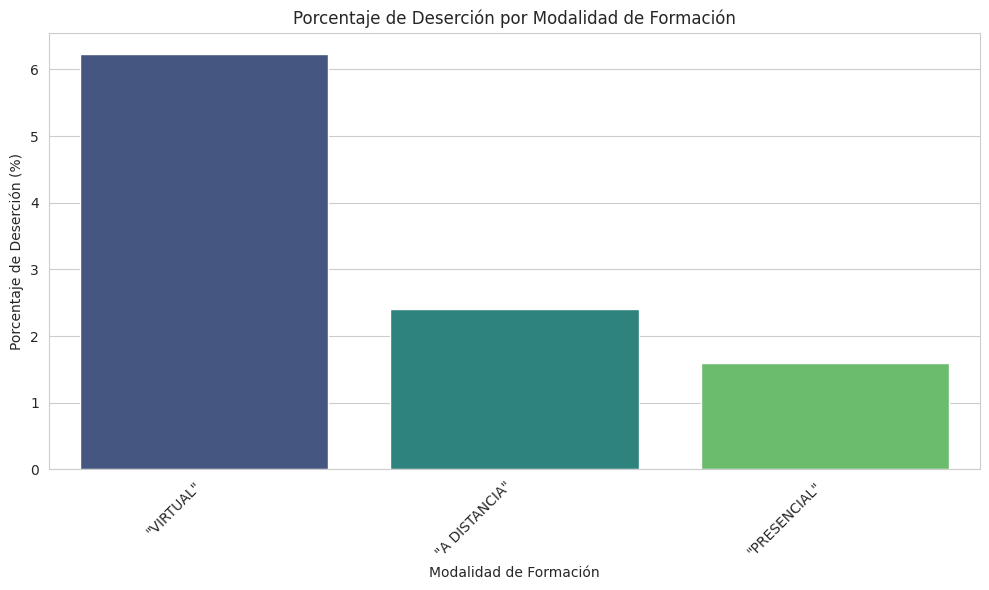

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=desertion_percentage_by_modality.index, y=desertion_percentage_by_modality.values, palette='viridis', hue=desertion_percentage_by_modality.index, legend=False)
plt.title('Porcentaje de Deserción por Modalidad de Formación')
plt.xlabel('Modalidad de Formación')
plt.ylabel('Porcentaje de Deserción (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusiones Clave del Análisis

1.  El centro con **más desertores en números absolutos** es el "CENTRO DE COMERCIO Y SERVICIOS".
2.  Sin embargo, el "CENTRO PARA LA BIODIVERSIDAD Y EL TURISMO DEL AMAZONAS" tiene el **porcentaje de deserción más alto**.
3.  La **modalidad "VIRTUAL"** muestra una tasa de deserción significativamente mayor en comparación con las otras modalidades.
4.  El **nivel de formación "EVENTO"** es el que presenta el mayor porcentaje de deserción.
5.  Existe una **asociación moderada** entre el Nivel de Formación y la Modalidad, lo que indica que no son completamente independientes.

**Análisis de Deserción por Centros de Formación**: tanto los centros con el mayor número absoluto de desertores como aquellos con el porcentaje de deserción más alto. Es importante destacar que estos no siempre son los mismos, lo que sugiere que algunos centros pueden tener muchos desertores debido a un gran volumen de estudiantes, mientras que otros, incluso con menos estudiantes, pueden tener un porcentaje de deserción alto.

**Análisis de Deserción por Modalidad de Formación**: La modalidad "VIRTUAL" mostró el porcentaje de deserción más elevado (6.24%), seguida por "A DISTANCIA" (2.40%) y "PRESENCIAL" (1.60%). Esto indica que la virtualidad podría ser un factor que contribuye a una mayor tasa de deserción, lo cual es un hallazgo clave para futuras estrategias de retención.

**Análisis de Deserción por Nivel de Formación**: El nivel de formación "EVENTO" es el que presenta el porcentaje de deserción más alto (10.44%), seguido de "CURSO ESPECIAL" (5.35%) y "OPERARIO" (4.41%). La "PROFUNDIZACION TECNICA" no registró deserción en los datos analizados. Esto nos da una idea de qué tipos de formación pueden ser más susceptibles a la deserción.

**Correlación entre Nivel de Formación y Modalidad**: Hay una asociación moderada entre el nivel de formación y la modalidad, con un coeficiente V de Cramer de 0.31. Esto significa que existe una relación discernible entre cómo se distribuyen los diferentes niveles de formación entre las modalidades (presencial, a distancia, virtual). Por ejemplo, algunos niveles de formación tienden a ser ofrecidos predominantemente en ciertas modalidades.

En resumen, este análisis ha proporcionado una comprensión detallada de los factores que influyen en la deserción, ofreciendo puntos de partida claros para la toma de decisiones y la implementación de estrategias de mejora.